# Top Brand TF-IDF Wordcloud (제품명)

표본 수(상품 문서 수) 기준 **상위 10개 브랜드**에 대해,
브랜드 내부에서 **상품 1개 = 문서 1개** TF-IDF를 적용하고 워드클라우드로 키워드를 비교합니다.

In [1]:
# %pip install scikit-learn pandas matplotlib wordcloud

from __future__ import annotations

import re
import sys
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

import wordcloud_lab as wl

In [2]:
RUNS_DIR = PROJECT_ROOT / "runs"
OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "output" / "product_name_top_brand_tfidf"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RUN_DIR: Path | None = None

TOP_N_BRANDS = 10
MIN_PRODUCTS_PER_BRAND = 50
TOP_K = 40
NGRAM_RANGE = (1, 2)
MIN_DF_RATIO = 0.005
MAX_DF_RATIO = 0.35
USE_SUBLINEAR_TF = True
FILTER_BRAND_NAME_IN_TOKENS = True
SHOW_RAW_VS_FILTERED = True
SAVE_CSV = True

In [3]:
run_dir = wl.resolve_run_dir(RUNS_DIR, RUN_DIR)
items = wl.load_items(run_dir)
font_path, _ = wl.init_fonts()
if font_path:
    print(f"font: {font_path}")
print(f"run: {run_dir.name}")

font: /System/Library/Fonts/Supplemental/AppleGothic.ttf
run: 20260527_172433


In [4]:
def brand_key(item: dict) -> tuple[str, str]:
    brand = str(item.get("brand") or "").strip()
    brand_id = str(item.get("brand_id") or "").strip()
    return brand, brand_id


def safe_slug(text: str) -> str:
    slug = re.sub(r"[^0-9A-Za-z가-힣_-]+", "_", text).strip("_")
    return slug or "brand"


def brand_name_stopwords(brand: str) -> frozenset[str]:
    if not FILTER_BRAND_NAME_IN_TOKENS or not brand:
        return frozenset()
    toks = set(wl.tokenize_product_name(brand))
    compact = brand.replace(" ", "").lower()
    if compact:
        toks.add(compact)
    return frozenset(toks)


def count_term_in_tokens(term: str, tokens: list[str]) -> int:
    parts = term.split()
    n = len(parts)
    if n == 1:
        return tokens.count(term)
    return sum(1 for i in range(len(tokens) - n + 1) if tokens[i : i + n] == parts)


def count_term_in_docs(term: str, docs_tokens: list[list[str]]) -> int:
    return sum(count_term_in_tokens(term, toks) for toks in docs_tokens)


def build_brand_product_docs(items: list[dict], target_brands: set[str]) -> pd.DataFrame:
    ubiquitous = wl.ubiquitous_for_items(items)
    rows: list[dict] = []

    for it in wl.product_items(items):
        brand, brand_id = brand_key(it)
        if not brand or brand not in target_brands:
            continue

        code, label = wl.category_key(it)
        if code in wl.SKIP_CATEGORY_CODES:
            continue

        name = wl.product_display_name(it)
        if not name:
            continue

        stop = wl.generic_stopwords_for(code, label, ubiquitous) | brand_name_stopwords(brand)
        toks = [t for t in wl.tokenize_product_name(name) if t not in stop]
        if not toks:
            continue

        rows.append(
            {
                "brand": brand,
                "brand_id": brand_id,
                "category_code": code,
                "category_label": label,
                "tokens": toks,
                "doc": " ".join(toks),
            }
        )

    return pd.DataFrame(rows)


def run_tfidf_for_brand(brand_docs: pd.DataFrame) -> pd.DataFrame:
    n_docs = len(brand_docs)
    min_df = max(1, int(np.ceil(n_docs * MIN_DF_RATIO)))
    vectorizer = TfidfVectorizer(
        tokenizer=str.split,
        preprocessor=None,
        token_pattern=None,
        lowercase=False,
        ngram_range=NGRAM_RANGE,
        min_df=min_df,
        max_df=MAX_DF_RATIO,
        sublinear_tf=USE_SUBLINEAR_TF,
    )
    X = vectorizer.fit_transform(brand_docs["doc"].tolist())
    terms = np.array(vectorizer.get_feature_names_out())
    tfidf_sum = np.asarray(X.sum(axis=0)).ravel()
    df_ratio = np.asarray((X > 0).sum(axis=0)).ravel() / n_docs
    order = np.argsort(tfidf_sum)[::-1][:TOP_K]

    docs_tokens = brand_docs["tokens"].tolist()
    rows = []
    for rank, j in enumerate(order, start=1):
        term = terms[j]
        rows.append(
            {
                "rank": rank,
                "term": term,
                "tfidf": float(tfidf_sum[j]),
                "doc_freq_ratio": float(df_ratio[j]),
                "count": count_term_in_docs(term, docs_tokens),
            }
        )
    return pd.DataFrame(rows)

In [5]:
brand_counts = Counter()
for it in wl.product_items(items):
    brand, _ = brand_key(it)
    if brand:
        brand_counts[brand] += 1

top_brands = [b for b, _ in brand_counts.most_common(TOP_N_BRANDS)]
target_brands = set(top_brands)

brand_rank_df = pd.DataFrame(
    [
        {"rank": i + 1, "brand": b, "product_rows": brand_counts[b]}
        for i, b in enumerate(top_brands)
    ]
)
display(brand_rank_df)

brand_docs_df = build_brand_product_docs(items, target_brands)
if brand_docs_df.empty:
    raise ValueError("상위 브랜드 문서가 비어 있습니다.")

brand_docs_stats = (
    brand_docs_df.groupby("brand", as_index=False)
    .agg(
        product_docs=("doc", "count"),
        token_count=("tokens", lambda s: int(sum(len(x) for x in s))),
        category_variety=("category_code", "nunique"),
    )
    .sort_values("product_docs", ascending=False)
)
brand_docs_stats

,rank,brand,product_rows
0,1,무신사 스탠다드,1320
1,2,무신사 스탠다드 우먼,827
2,3,아디다스,542
3,4,드래곤 디퓨전,285
4,5,디미트리블랙,257
5,6,마뗑킴,232
6,7,언탭트 스튜디오,195
7,8,잔스포츠,173
8,9,키뮤어,141
9,10,노스페이스,140


,brand,product_docs,token_count,category_variety
4,무신사 스탠다드,1320,4653,4
5,무신사 스탠다드 우먼,827,2827,4
6,아디다스,542,1695,4
1,드래곤 디퓨전,285,881,1
2,디미트리블랙,257,1209,3
3,마뗑킴,232,685,3
7,언탭트 스튜디오,195,870,3
8,잔스포츠,173,345,1
9,키뮤어,141,568,2
0,노스페이스,140,423,3


In [6]:
all_top_terms: list[pd.DataFrame] = []
brand_panels_filtered: list[tuple[str, Counter]] = []
brand_panels_raw: list[tuple[str, Counter]] = []
brand_panel_map: dict[str, tuple[tuple[str, Counter], tuple[str, Counter]]] = {}

for brand in top_brands:
    sub = brand_docs_df[brand_docs_df["brand"] == brand].copy()
    if len(sub) < MIN_PRODUCTS_PER_BRAND:
        print(f"skip {brand}: n_docs={len(sub)} (<{MIN_PRODUCTS_PER_BRAND})")
        continue

    top_df = run_tfidf_for_brand(sub)
    top_df.insert(0, "brand", brand)
    all_top_terms.append(top_df)

    docs_tokens = sub["tokens"].tolist()
    raw_ctr = Counter(tok for toks in docs_tokens for tok in toks)
    filtered_ctr = Counter({row["term"]: int(row["count"]) for _, row in top_df.iterrows() if row["count"] > 0})

    n_docs = len(sub)
    n_tokens = sum(raw_ctr.values())
    subtitle = f"{brand} (n_docs={n_docs:,}, n_tokens={n_tokens:,})"
    raw_panel = (f"{subtitle} — 원본", raw_ctr)
    flt_panel = (f"{subtitle} — TF-IDF", filtered_ctr)
    brand_panels_raw.append(raw_panel)
    brand_panels_filtered.append(flt_panel)
    brand_panel_map[brand] = (raw_panel, flt_panel)

top_terms_df = pd.concat(all_top_terms, ignore_index=True)
print(f"브랜드 패널 수: {len(brand_panels_filtered)}")

브랜드 패널 수: 10


## 워드클라우드 (상위 10 브랜드)

글자 크기 = 해당 브랜드 내 **원본 토큰 빈도**. 제목의 `n_docs`는 상품 문서 수, `n_tokens`는 토큰 출현 합입니다.

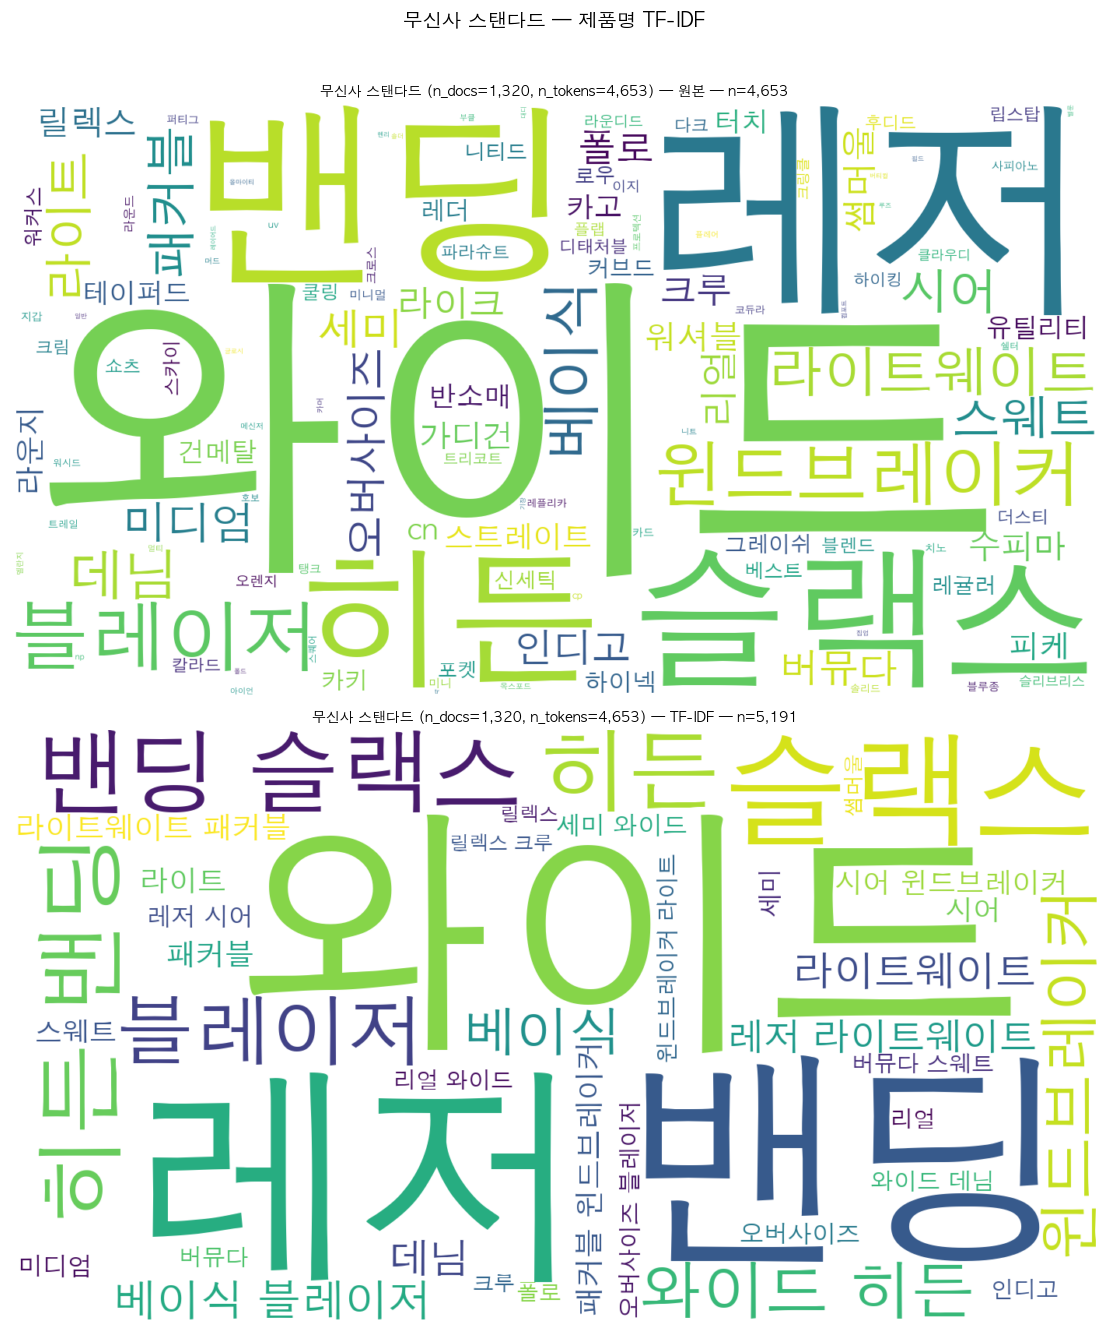

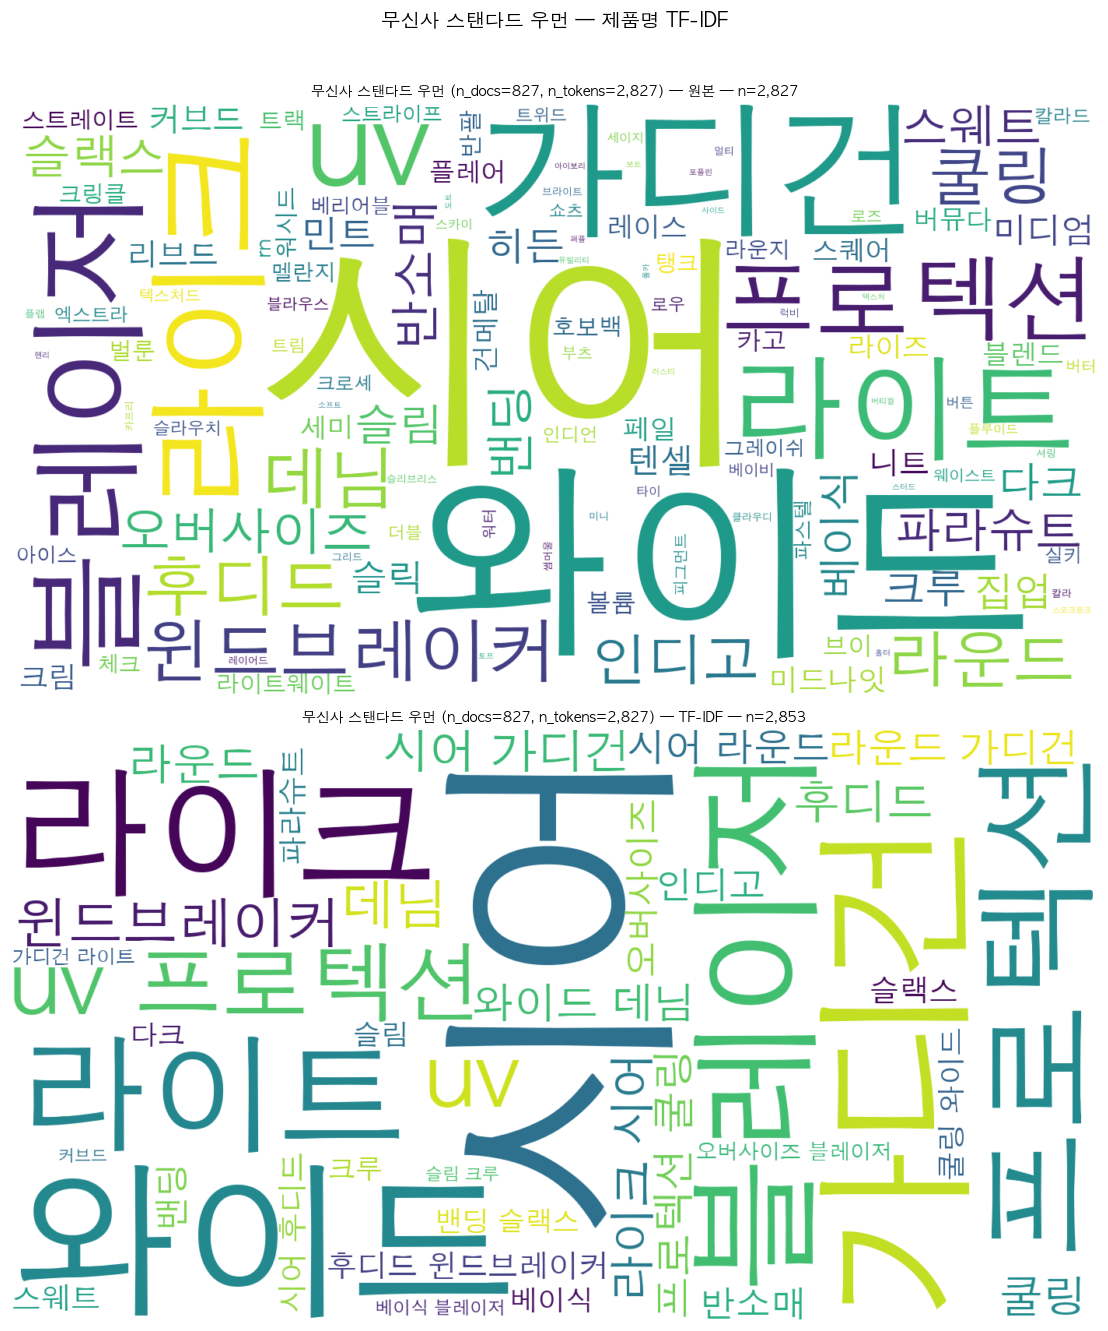

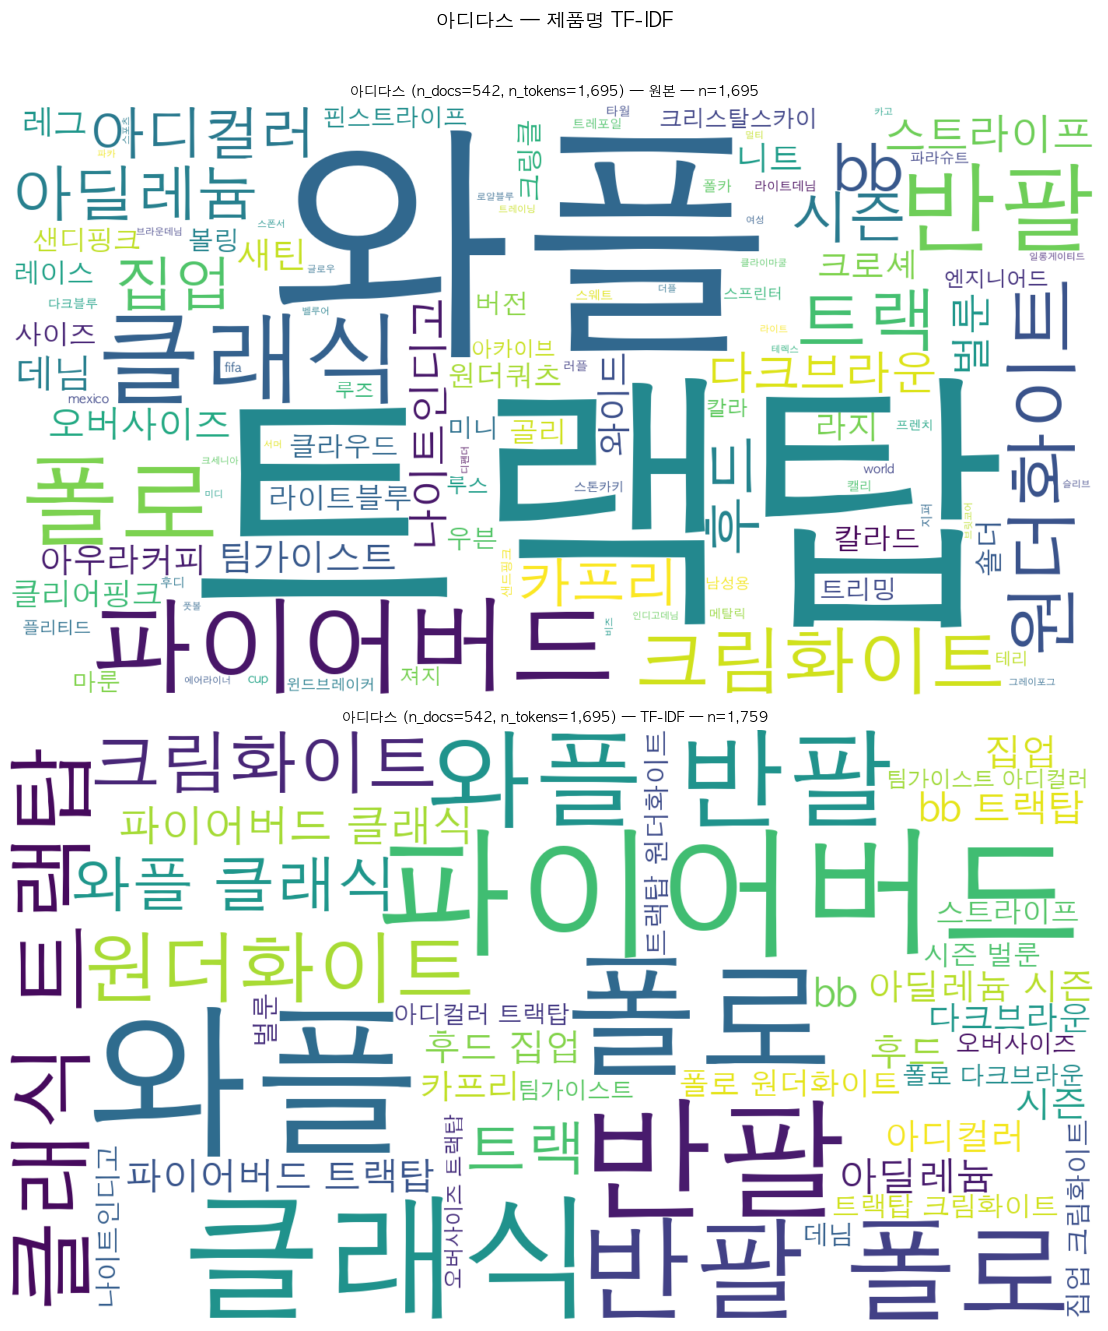

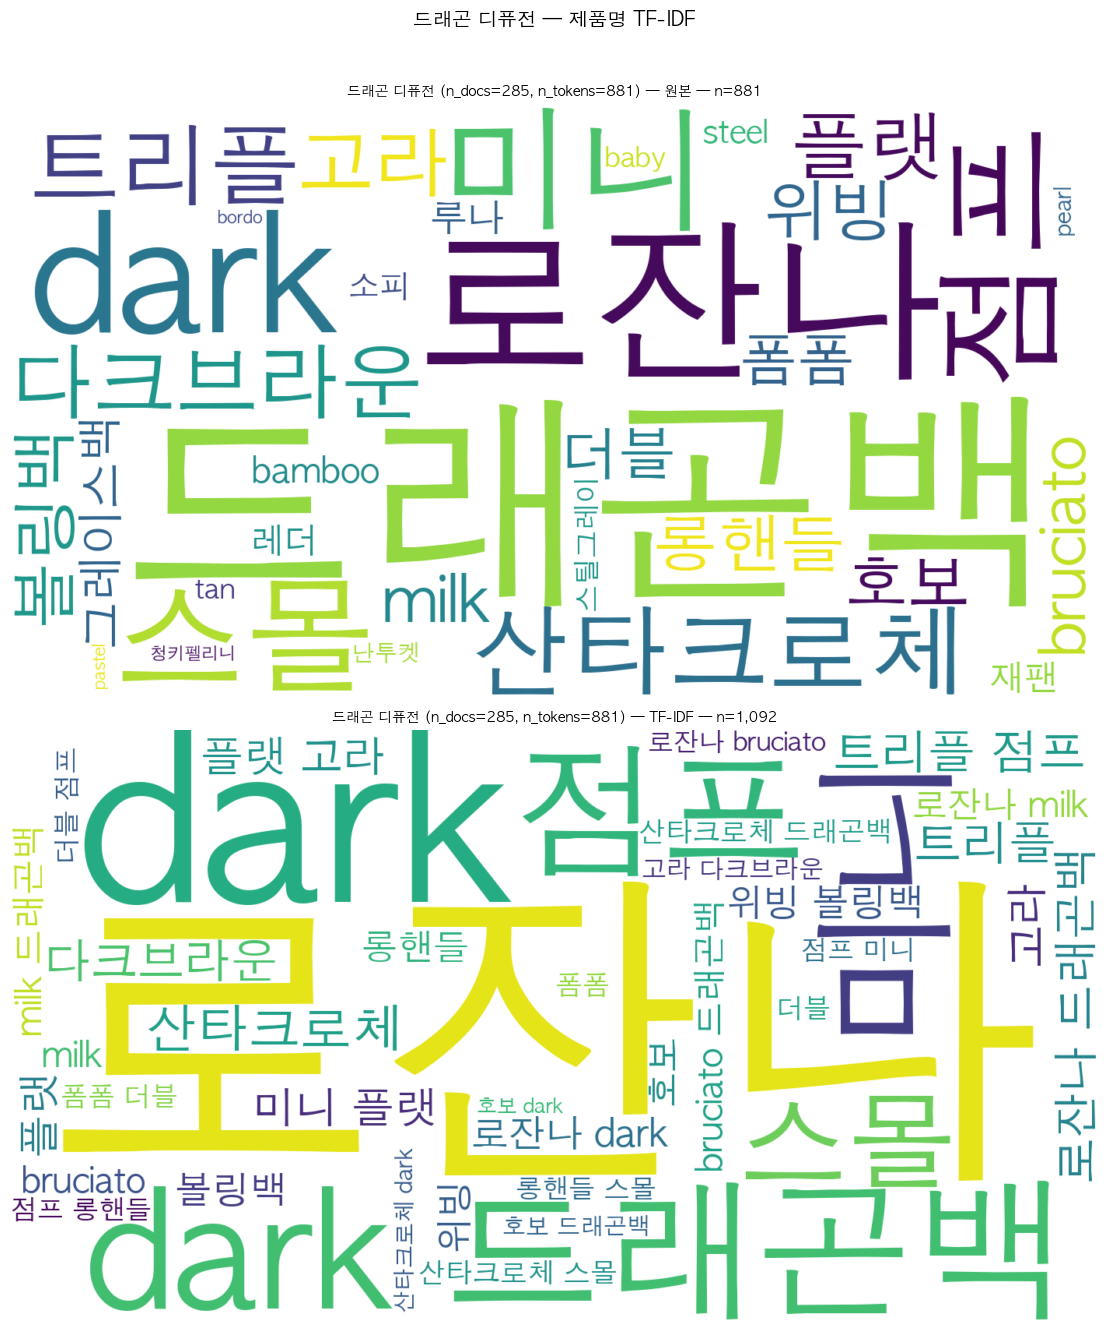

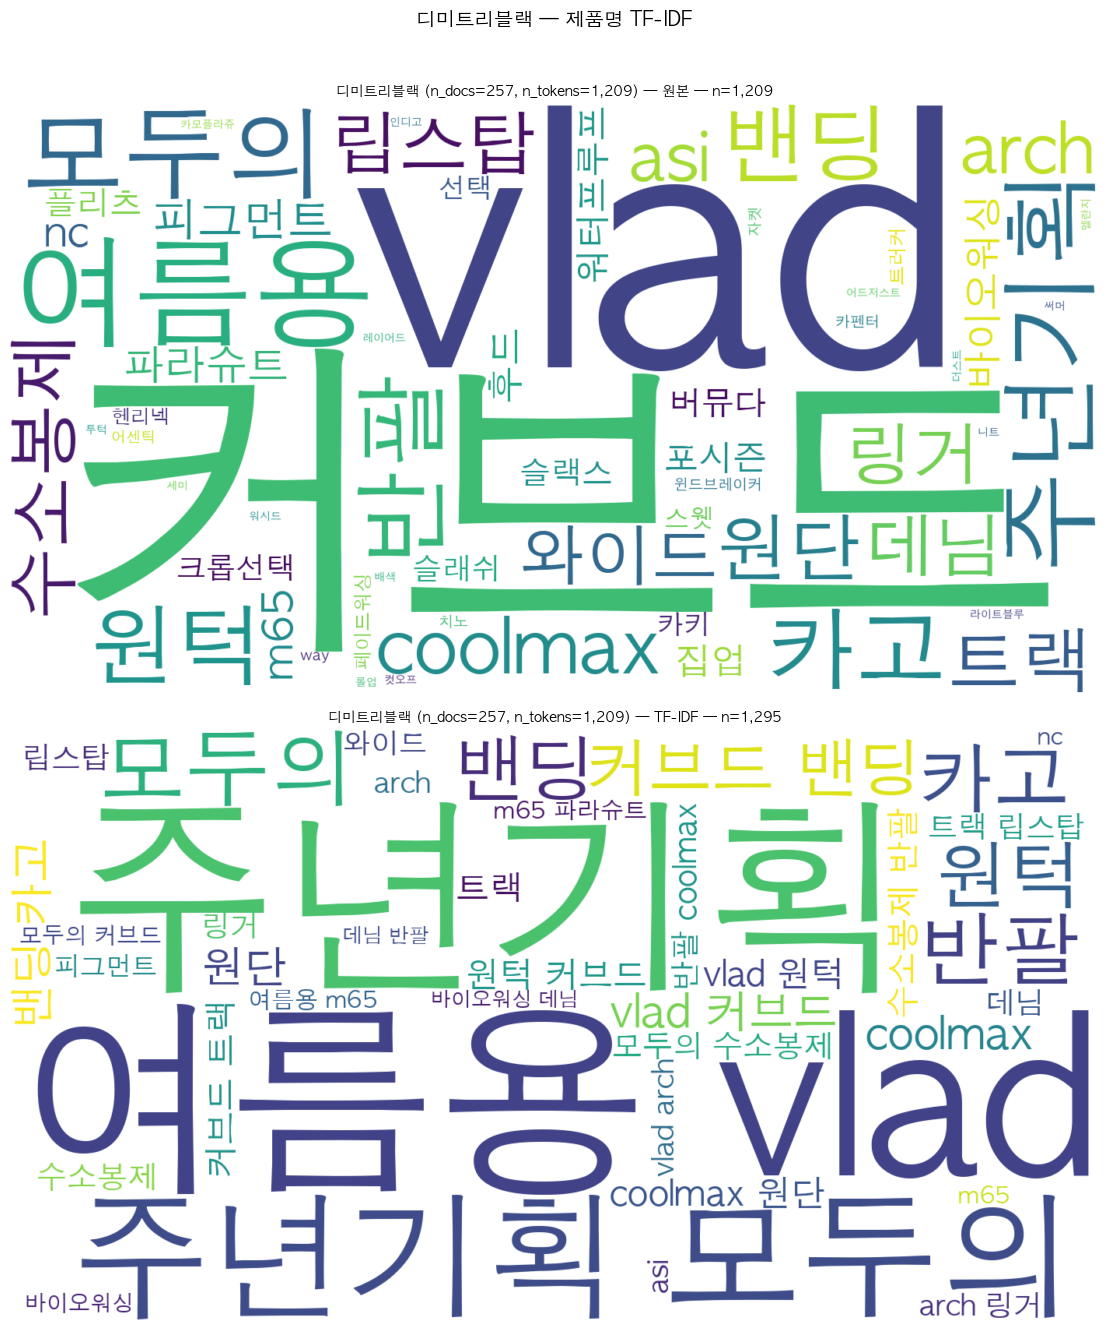

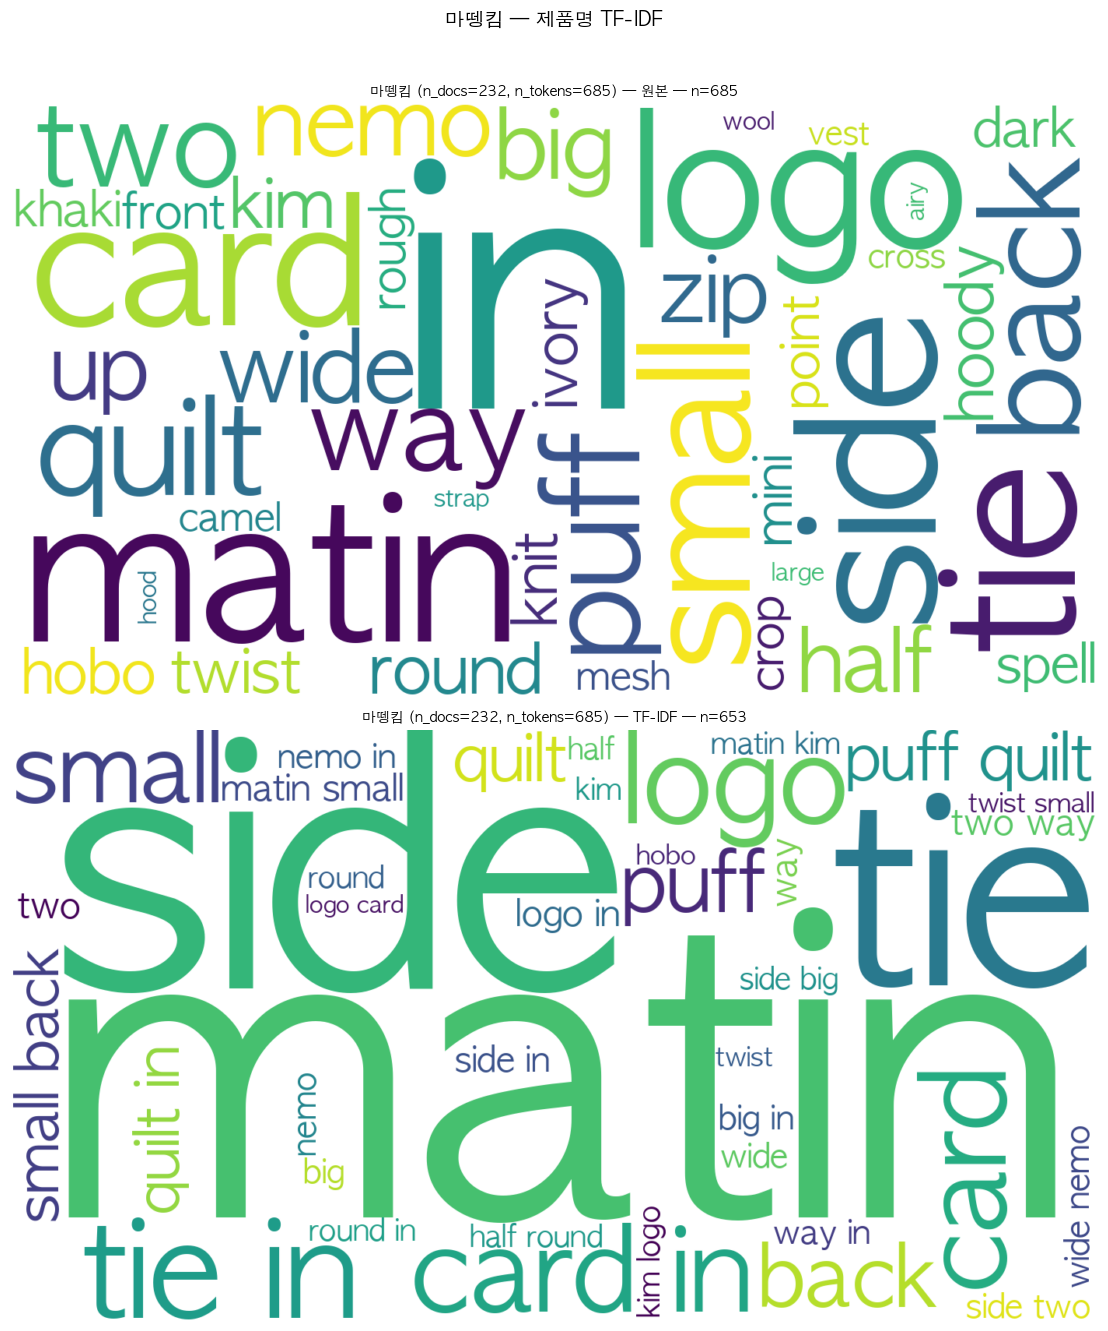

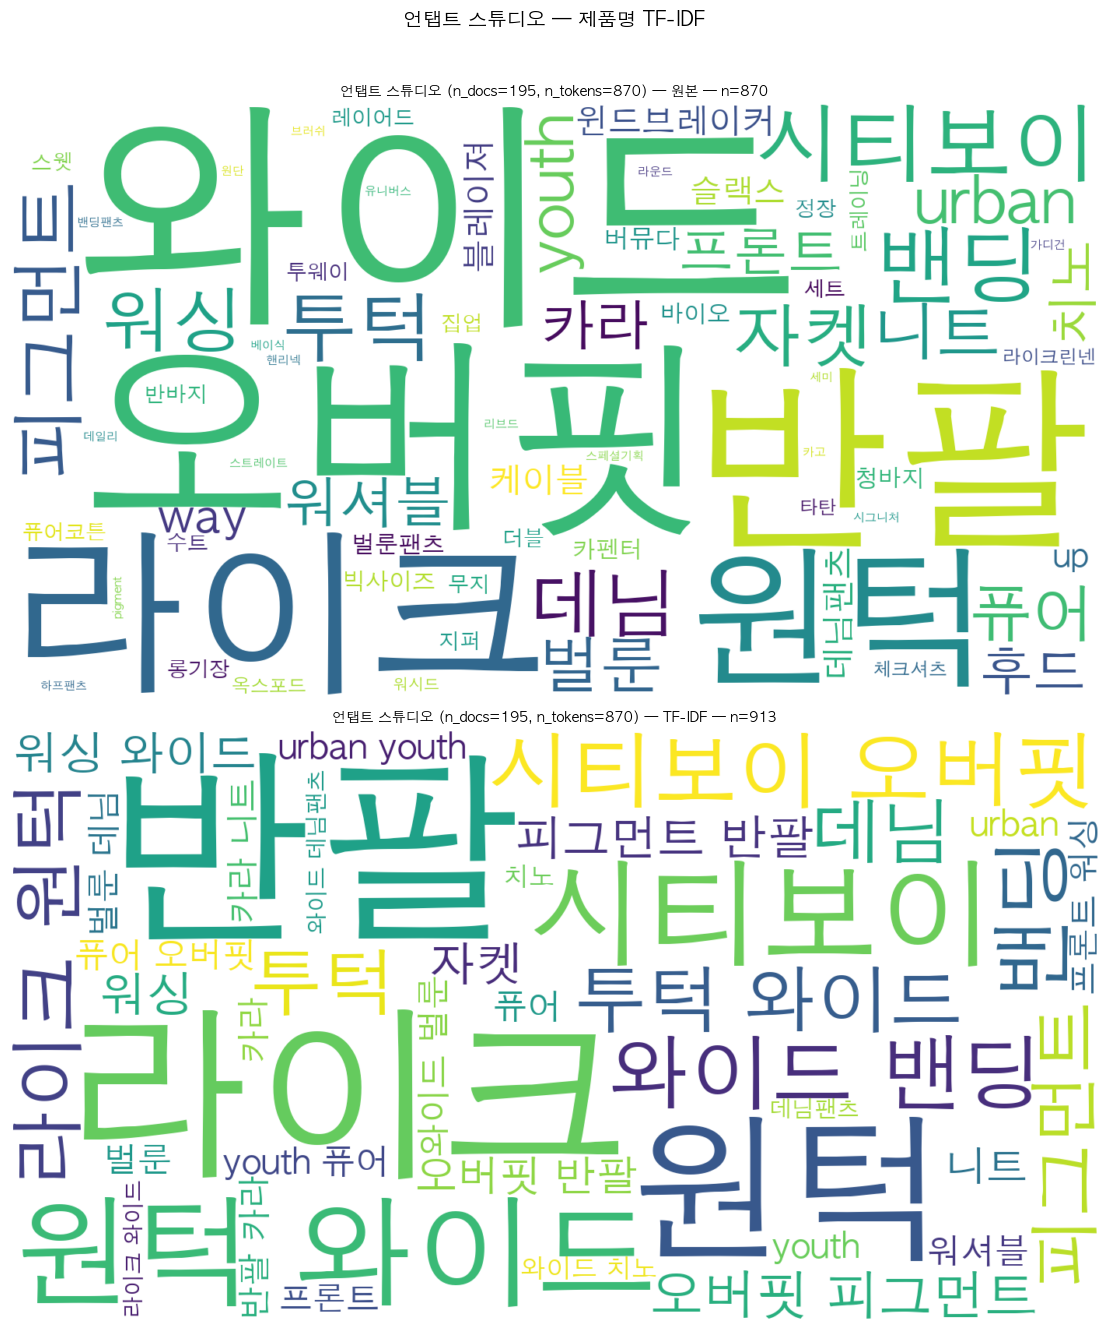

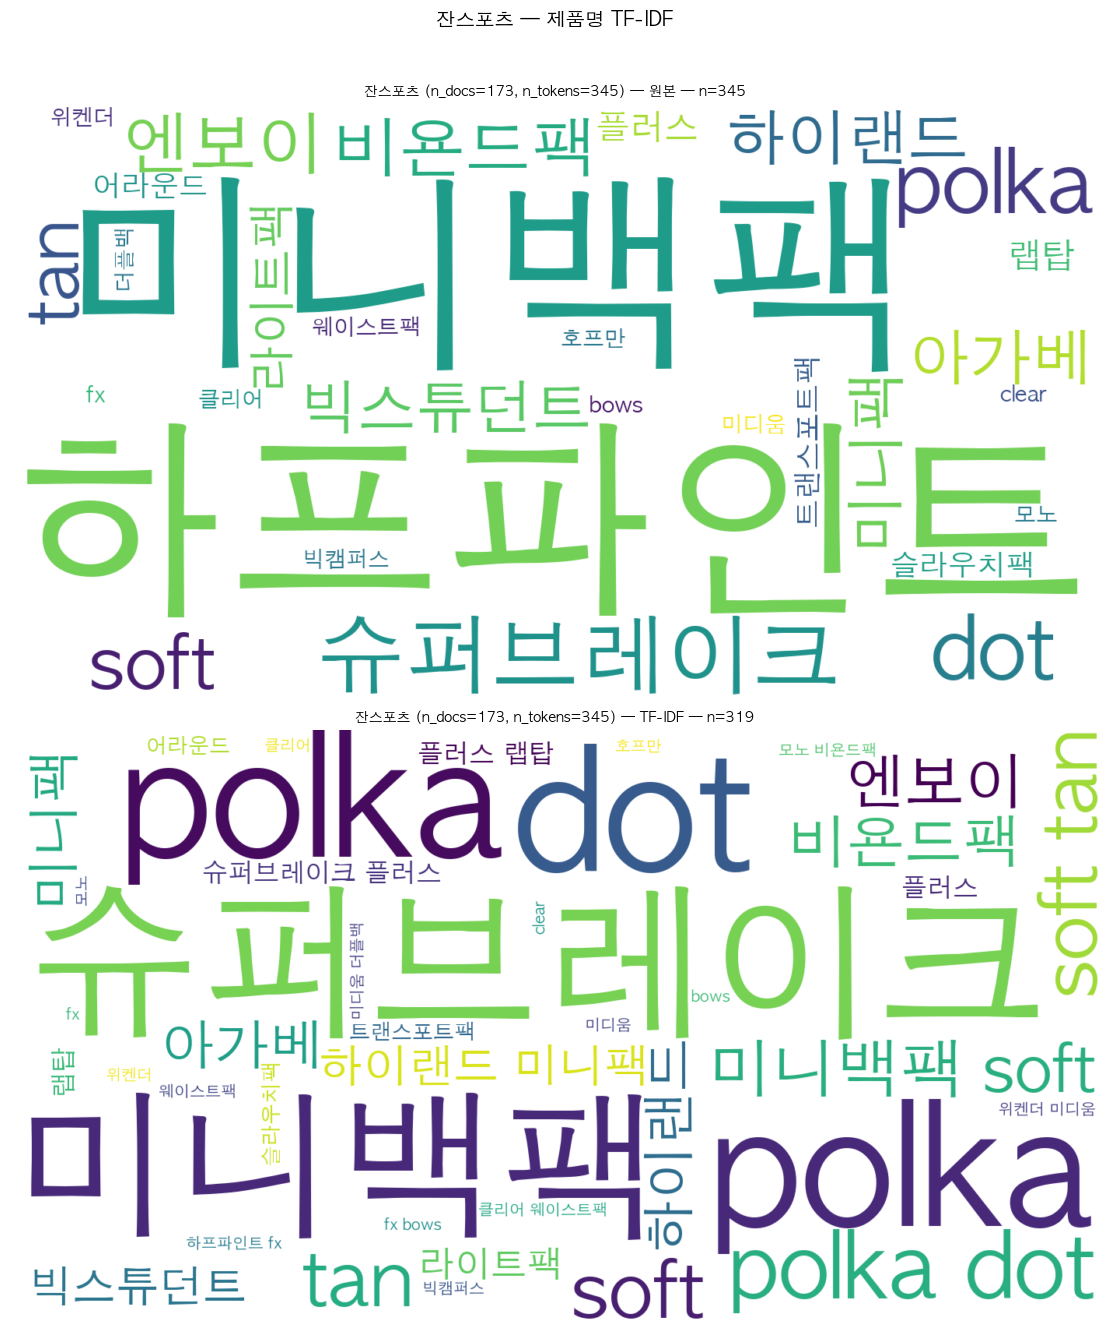

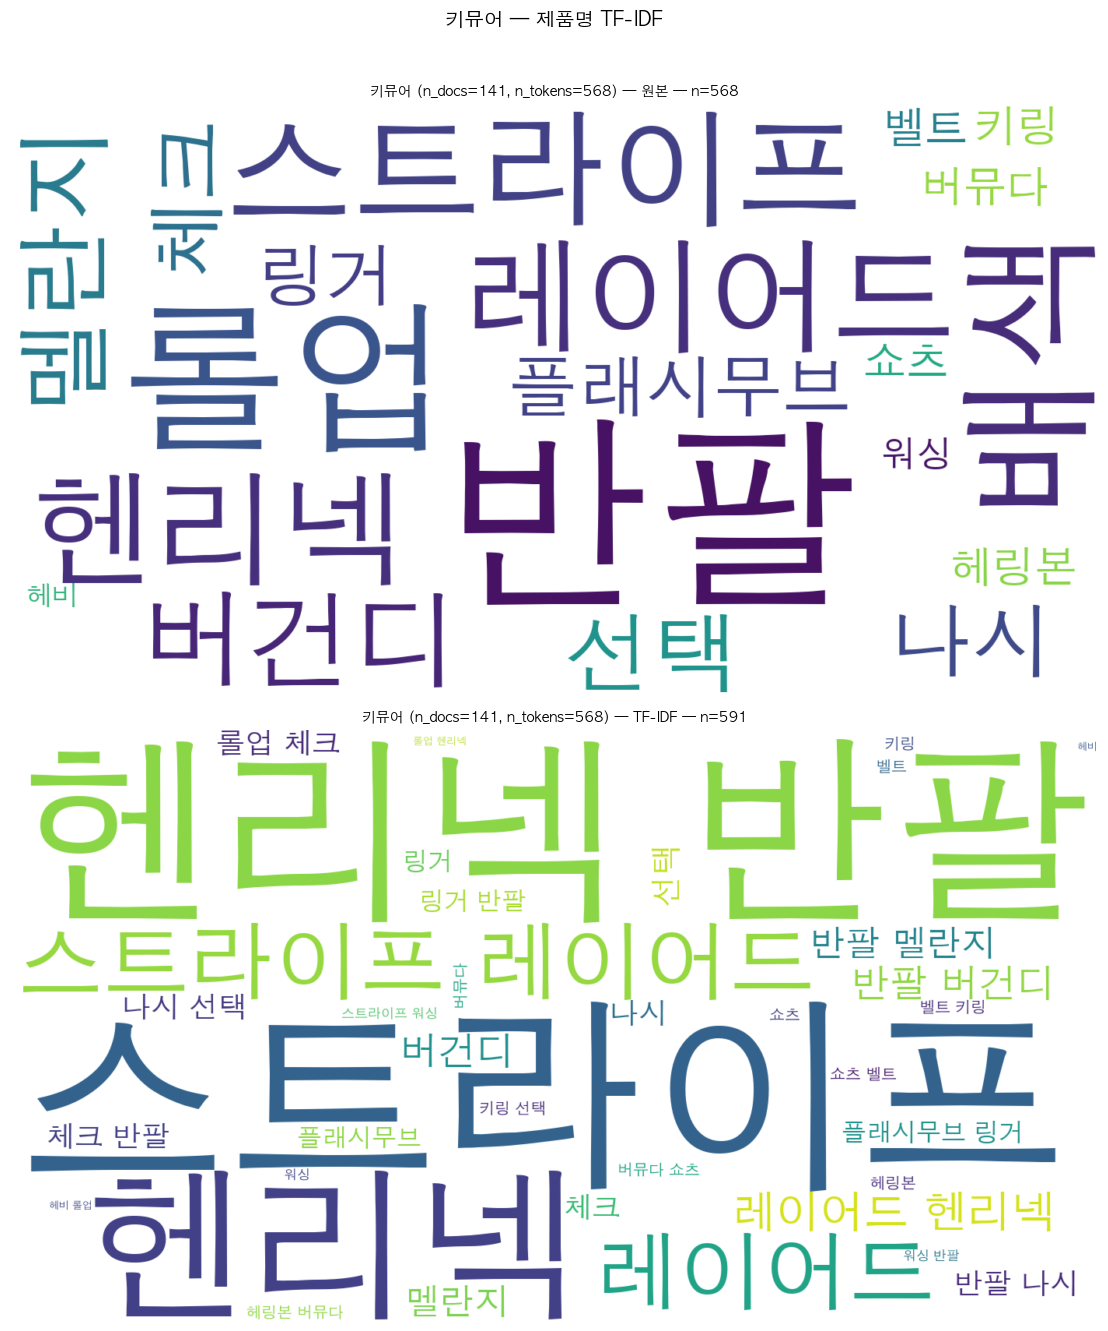

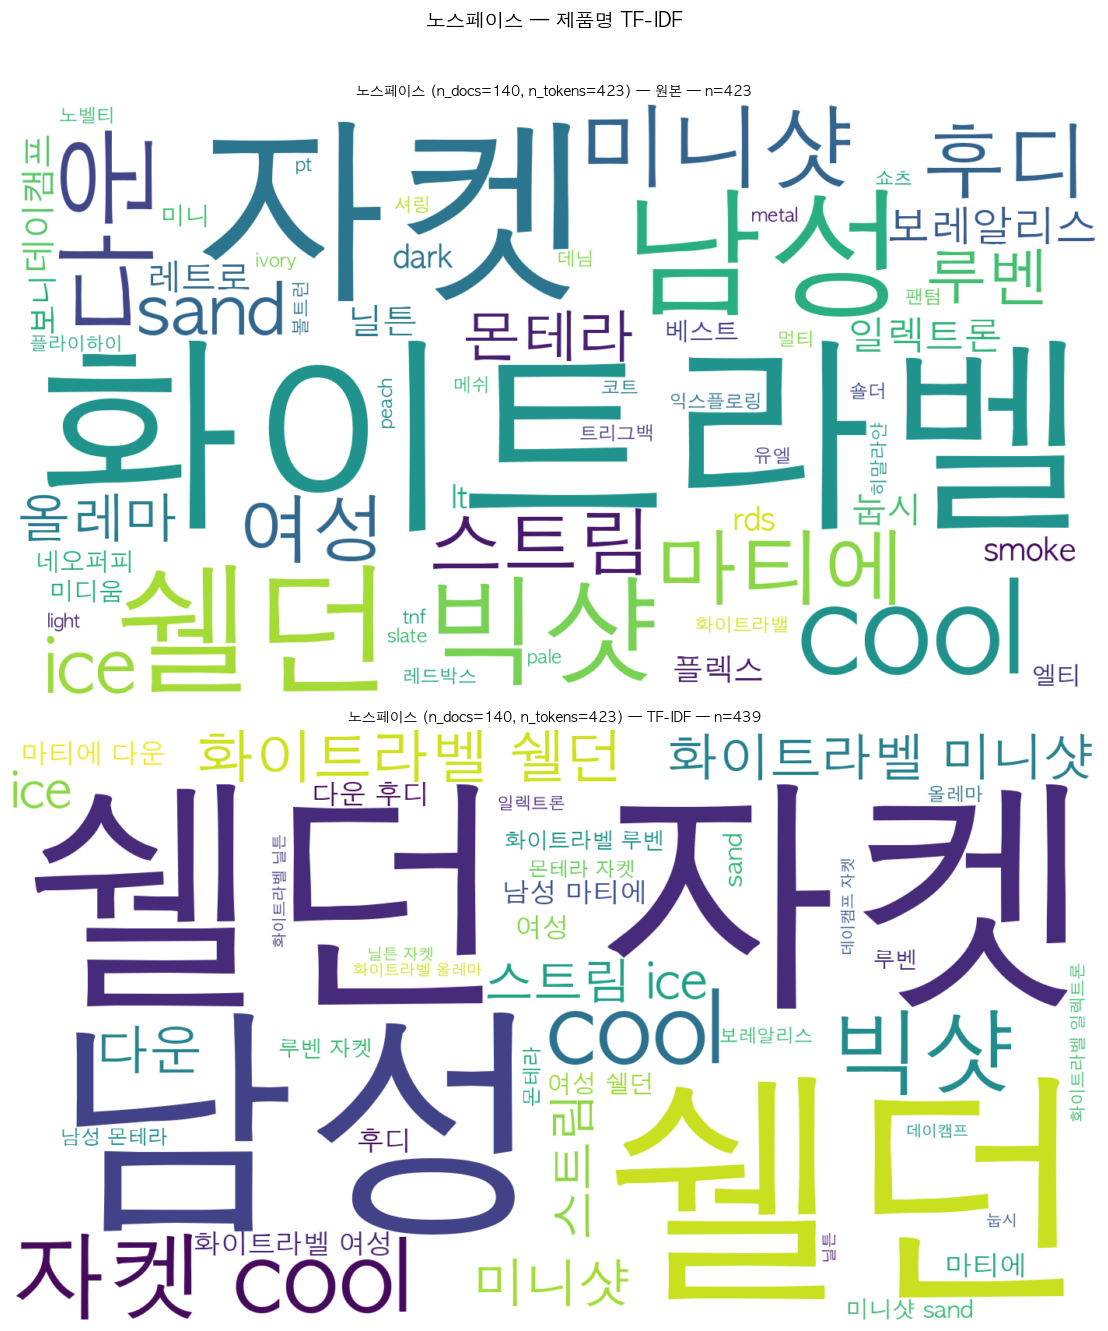

In [7]:
run_name = run_dir.name

for brand in top_brands:
    if brand not in brand_panel_map:
        continue
    raw_panel, flt_panel = brand_panel_map[brand]
    panels = [raw_panel, flt_panel] if SHOW_RAW_VS_FILTERED else [flt_panel]

    wl.plot_wordcloud_column(
        panels,
        suptitle=f"{brand} — 제품명 TF-IDF",
        figsize_per_cell=(14.0, 6.5),
        wordcloud_width=1400,
        wordcloud_height=760,
        save_path=OUTPUT_DIR / f"{run_name}_{safe_slug(brand)}_brand_tfidf_wordcloud.png",
    )

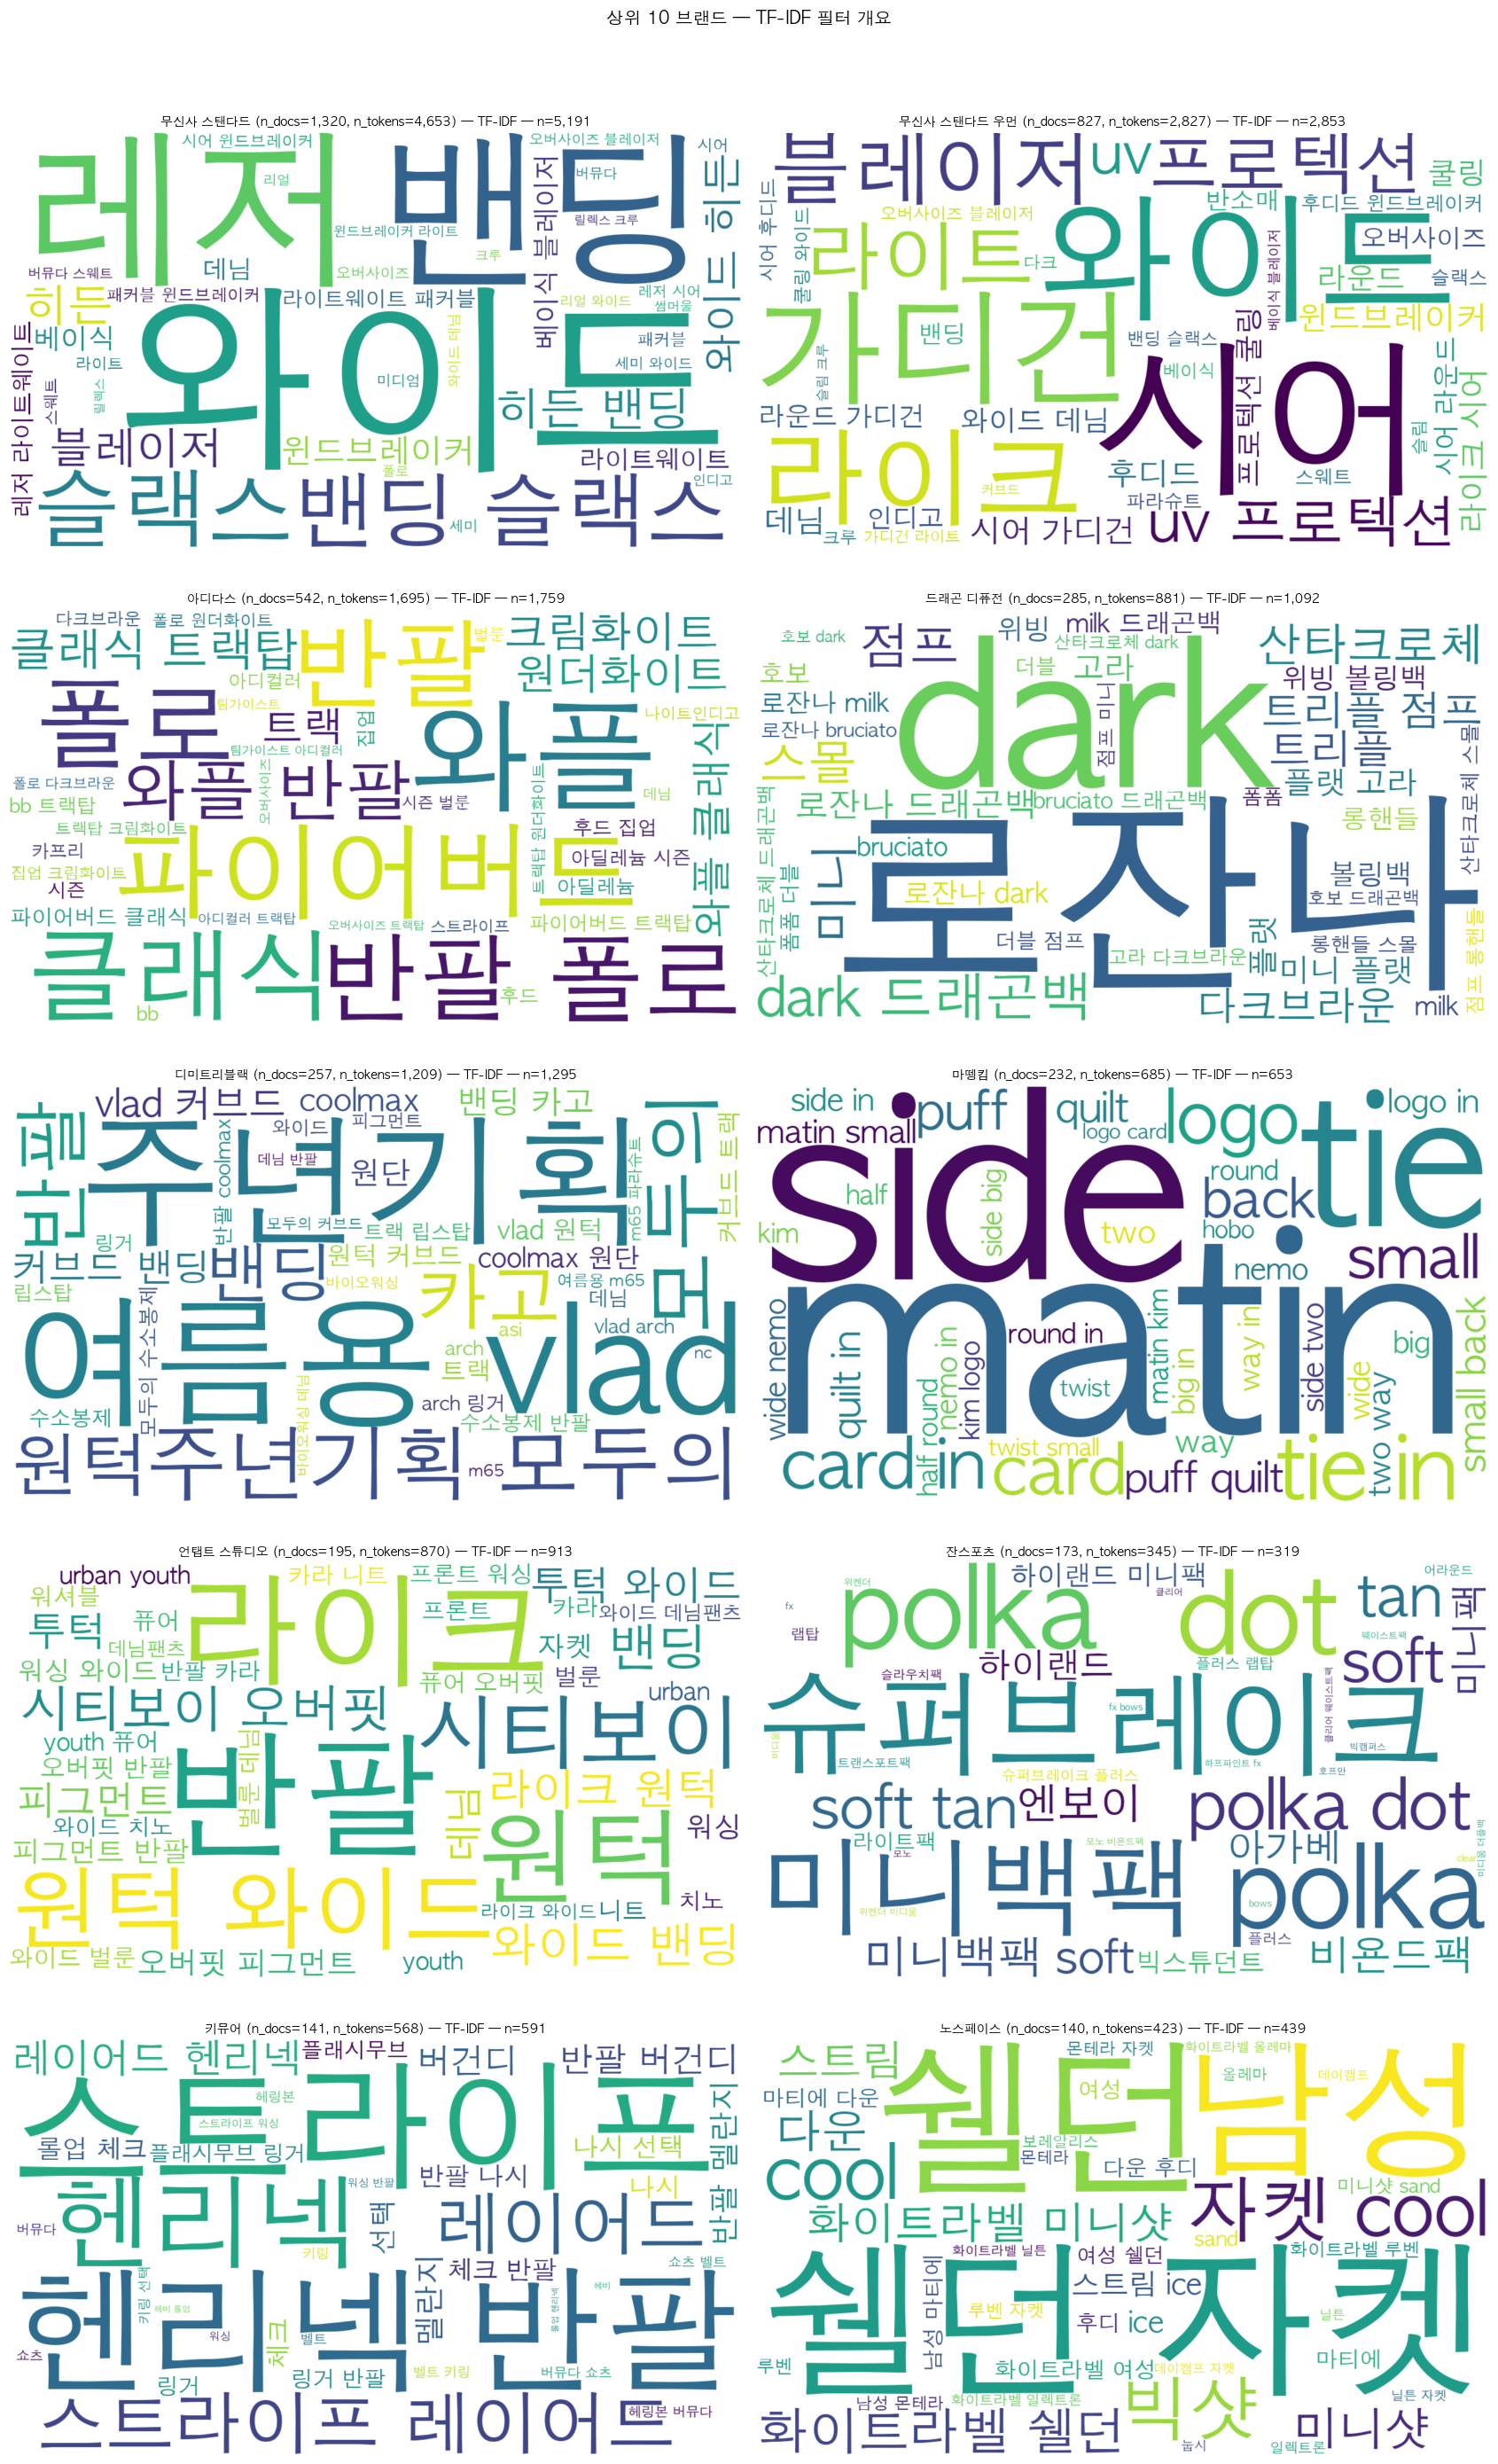

In [8]:
# 전체 개요: TF-IDF 필터만 2열 그리드
wl.plot_wordcloud_grid(
    brand_panels_filtered,
    suptitle=f"상위 {TOP_N_BRANDS} 브랜드 — TF-IDF 필터 개요",
    ncols=2,
    figsize_per_cell=(8.5, 5.5),
    wordcloud_width=1200,
    wordcloud_height=680,
    save_path=OUTPUT_DIR / f"{run_name}_top{TOP_N_BRANDS}_brand_tfidf_overview.png",
)

In [9]:
for brand, group in top_terms_df.groupby("brand", sort=False):
    print(f"\n=== {brand} ===")
    display(group[["rank", "term", "count", "doc_freq_ratio", "tfidf"]].head(20))


=== 무신사 스탠다드 ===


,rank,term,count,doc_freq_ratio,tfidf
0,1,블레이저,238,0.180303,102.312188
1,2,와이드,395,0.299242,99.184076
2,3,밴딩,289,0.218939,83.433926
3,4,슬랙스,264,0.200000,79.104307
4,5,밴딩 슬랙스,261,0.197727,78.704252
5,6,베이식,151,0.114394,78.334551
6,7,레저,303,0.229545,77.690659
7,8,히든 밴딩,256,0.193939,77.356819
8,9,히든,256,0.193939,77.356819
9,10,베이식 블레이저,146,0.110606,76.763913



=== 무신사 스탠다드 우먼 ===


,rank,term,count,doc_freq_ratio,tfidf
40,1,시어,254,0.307134,69.206682
41,2,가디건,163,0.197098,52.517353
42,3,와이드,168,0.203144,44.567940
43,4,블레이저,107,0.129383,44.447768
44,5,라이크,114,0.137848,42.046957
45,6,시어 가디건,84,0.101572,36.149703
46,7,라이크 시어,84,0.101572,36.149703
47,8,파라슈트,46,0.055623,33.902872
48,9,윈드브레이커,88,0.106409,32.560649
49,10,라이트,94,0.113664,32.536603



=== 아디다스 ===


...

,rank,term,count,doc_freq_ratio,tfidf
280,1,슈퍼브레이크,26,0.150289,23.861923
281,2,엔보이,15,0.086705,15.000000
282,3,비욘드팩,14,0.080925,13.407664
283,4,미니백팩 polka,24,0.138728,12.000000
284,5,아가베,12,0.069364,12.000000
285,6,dot,24,0.138728,12.000000
286,7,polka,24,0.138728,12.000000
287,8,polka dot,24,0.138728,12.000000
288,9,빅스튜던트,11,0.063584,11.000000
289,10,soft tan,17,0.098266,8.500000



=== 키뮤어 ===


,rank,term,count,doc_freq_ratio,tfidf
320,1,반팔 버건디,31,0.219858,18.107862
321,2,버건디,31,0.219858,18.107862
322,3,스트라이프,46,0.326241,17.370820
323,4,헨리넥 반팔,45,0.319149,17.279284
324,5,헨리넥,45,0.319149,17.279284
325,6,스트라이프 레이어드,44,0.312057,17.233921
326,7,레이어드,44,0.312057,17.233921
327,8,레이어드 헨리넥,44,0.312057,17.233921
328,9,멜란지,26,0.184397,14.420855
329,10,반팔 멜란지,26,0.184397,14.420855



=== 노스페이스 ===


,rank,term,count,doc_freq_ratio,tfidf
357,1,빅샷,18,0.128571,18.000000
358,2,쉘던 자켓,27,0.192857,10.859886
359,3,쉘던,27,0.192857,10.859886
360,4,화이트라벨 쉘던,17,0.121429,8.640398
361,5,자켓 cool,19,0.135714,8.306037
362,6,cool,19,0.135714,8.306037
363,7,남성,27,0.192857,7.950777
364,8,미니샷,14,0.100000,7.436332
365,9,화이트라벨 미니샷,13,0.092857,7.186462
366,10,스트림,12,0.085714,6.928203


In [10]:
if SAVE_CSV:
    tag = f"{run_name}_top{TOP_N_BRANDS}_brand_tfidf"
    top_terms_df.to_csv(OUTPUT_DIR / f"{tag}_top_terms.csv", index=False, encoding="utf-8-sig")
    brand_rank_df.to_csv(OUTPUT_DIR / f"{tag}_brand_rank.csv", index=False, encoding="utf-8-sig")
    brand_docs_stats.to_csv(OUTPUT_DIR / f"{tag}_brand_docs_stats.csv", index=False, encoding="utf-8-sig")
    print("saved:", OUTPUT_DIR / f"{tag}_top_terms.csv")

saved: /Users/bhc/dev/datadrift/v1/datadrift_app_engine/v2/silhouette_outliner/notebooks/output/product_name_top_brand_tfidf/20260527_172433_top10_brand_tfidf_top_terms.csv
